# Normalization Techniques — Theory

> *"By normalizing the inputs to each layer, we can ensure they have the same distribution regardless of the parameters — dramatically accelerating training."*
> — Ioffe & Szegedy, 2015

Interactive theory notebook covering BatchNorm, LayerNorm, RMSNorm, GroupNorm, SpectralNorm, AdaIN, AdaLN-Zero, loss landscape smoothing, and numerical stability.

In [1]:
import numpy as np
import scipy.linalg as la
import scipy.special as scs

try:
    import matplotlib.pyplot as plt
    import matplotlib
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['figure.figsize'] = [12, 5]
    plt.rcParams['font.size'] = 12
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

np.set_printoptions(precision=6, suppress=True)
np.random.seed(42)

COLORS = {
    'primary':   '#0077BB',
    'secondary': '#EE7733',
    'tertiary':  '#009988',
    'error':     '#CC3311',
    'neutral':   '#555555',
    'purple':    '#AA3377',
}

def check_close(name, got, expected, tol=1e-5):
    ok = np.allclose(got, expected, atol=tol, rtol=tol)
    print(f"{'PASS' if ok else 'FAIL'} — {name}")
    return ok

def check_true(name, cond):
    print(f"{'PASS' if cond else 'FAIL'} — {name}")
    return cond

print('Setup complete. COLORS, check_close, check_true defined.')


Setup complete. COLORS, check_close, check_true defined.


---

## 1. Intuition and Motivation

### 1.4 Taxonomy by Normalisation Axis

All normalisation methods differ only in **which axes** of the input tensor $(N, C, H, W)$ are used to compute the statistics.

In [2]:
# === 1.4 Normalisation Axis Taxonomy ===

# Simulate a (N=4, C=8, H=4, W=4) activation tensor
np.random.seed(0)
x = np.random.randn(4, 8, 4, 4) * 3 + 2  # non-zero mean, non-unit var
N, C, H, W = x.shape
eps = 1e-5

def norm_axes(x, axes, eps=1e-5):
    """Normalise x over the given axes."""
    mu  = x.mean(axis=axes, keepdims=True)
    var = x.var(axis=axes, keepdims=True)
    return (x - mu) / np.sqrt(var + eps), mu, var

# Batch Norm: axes (0, 2, 3) = (N, H, W)
bn_out, bn_mu, bn_var = norm_axes(x, axes=(0, 2, 3))

# Layer Norm: axes (1, 2, 3) = (C, H, W)
ln_out, ln_mu, ln_var = norm_axes(x, axes=(1, 2, 3))

# Instance Norm: axes (2, 3) = (H, W)
in_out, in_mu, in_var = norm_axes(x, axes=(2, 3))

# Group Norm (G=4): reshape, norm, reshape back
G = 4
x_g = x.reshape(N, G, C//G, H, W)
gn_out_g, gn_mu, gn_var = norm_axes(x_g, axes=(2, 3, 4))
gn_out = gn_out_g.reshape(N, C, H, W)

print('Statistics shapes:')
print(f'  Batch Norm  μ: {bn_mu.shape}  → one mean per channel')
print(f'  Layer Norm  μ: {ln_mu.shape}  → one mean per sample')
print(f'  Instance Nm μ: {in_mu.shape}  → one mean per (sample, channel)')
print(f'  Group Norm  μ: {gn_mu.shape}  → one mean per (sample, group)')

# Verify normalised outputs have expected statistics
# BN: each channel across (N,H,W) should have mean≈0, var≈1
bn_check_mean = bn_out.mean(axis=(0, 2, 3))  # (C,)
bn_check_var  = bn_out.var(axis=(0, 2, 3))   # (C,)
check_close('BN output mean per channel ≈ 0', bn_check_mean, np.zeros(C), tol=1e-5)
check_close('BN output var per channel ≈ 1',  bn_check_var,  np.ones(C),  tol=1e-5)

# LN: each sample across (C,H,W) should have mean≈0, var≈1
ln_check_mean = ln_out.mean(axis=(1, 2, 3))  # (N,)
ln_check_var  = ln_out.var(axis=(1, 2, 3))   # (N,)
check_close('LN output mean per sample ≈ 0', ln_check_mean, np.zeros(N), tol=1e-5)
check_close('LN output var per sample ≈ 1',  ln_check_var,  np.ones(N),  tol=1e-5)

print('\nAll normalisation methods verified.')


Statistics shapes:
  Batch Norm  μ: (1, 8, 1, 1)  → one mean per channel
  Layer Norm  μ: (4, 1, 1, 1)  → one mean per sample
  Instance Nm μ: (4, 8, 1, 1)  → one mean per (sample, channel)
  Group Norm  μ: (4, 4, 1, 1, 1)  → one mean per (sample, group)
PASS — BN output mean per channel ≈ 0
PASS — BN output var per channel ≈ 1
PASS — LN output mean per sample ≈ 0
PASS — LN output var per sample ≈ 1

All normalisation methods verified.


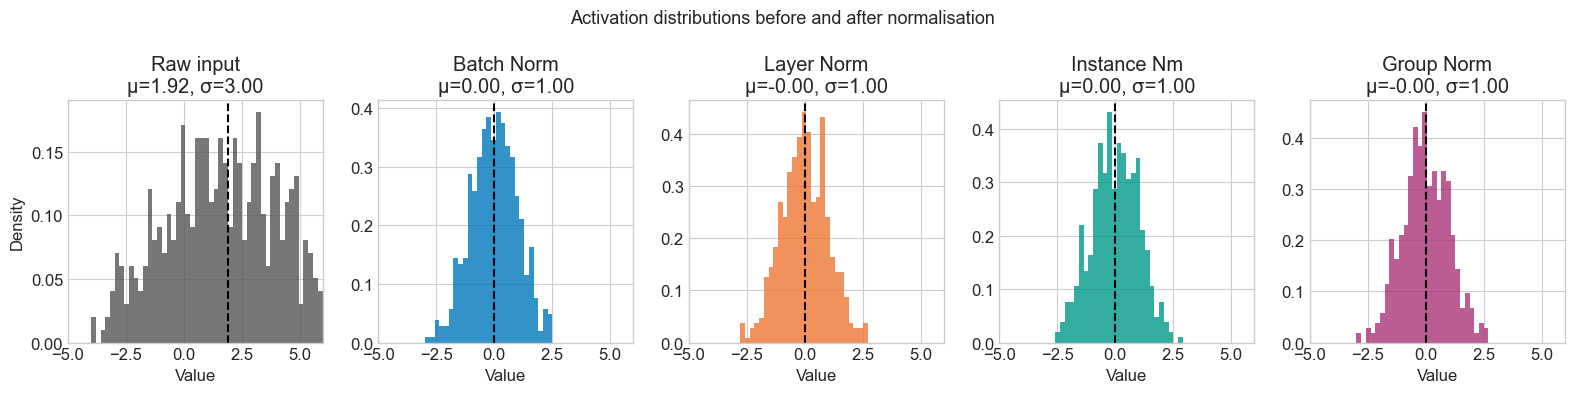

Raw input: mean=1.923, std=2.997
After BN:  mean=0.000, std=1.000
After LN:  mean=-0.000, std=1.000


In [3]:
# === 1.4 Visualisation of normalisation axes ===

if HAS_MPL:
    # Compare distributions of raw vs normalised activations
    fig, axes_arr = plt.subplots(1, 5, figsize=(16, 4))
    bins = np.linspace(-4, 8, 60)

    data_sets = [
        ('Raw input',   x.ravel(),      COLORS['neutral']),
        ('Batch Norm',  bn_out.ravel(),  COLORS['primary']),
        ('Layer Norm',  ln_out.ravel(),  COLORS['secondary']),
        ('Instance Nm', in_out.ravel(),  COLORS['tertiary']),
        ('Group Norm',  gn_out.ravel(),  COLORS['purple']),
    ]

    for ax, (name, data, color) in zip(axes_arr, data_sets):
        ax.hist(data, bins=bins, color=color, alpha=0.8, density=True)
        ax.axvline(data.mean(), color='k', lw=1.5, ls='--', label=f'μ={data.mean():.2f}')
        ax.set_title(f'{name}\nμ={data.mean():.2f}, σ={data.std():.2f}')
        ax.set_xlabel('Value')
        ax.set_xlim(-5, 6)

    axes_arr[0].set_ylabel('Density')
    fig.suptitle('Activation distributions before and after normalisation', fontsize=13)
    fig.tight_layout()
    plt.show()

print('Raw input: mean={:.3f}, std={:.3f}'.format(x.mean(), x.std()))
print('After BN:  mean={:.3f}, std={:.3f}'.format(bn_out.mean(), bn_out.std()))
print('After LN:  mean={:.3f}, std={:.3f}'.format(ln_out.mean(), ln_out.std()))


---

## 2. Formal Definitions

The general normalisation map: $\operatorname{Norm}(\mathbf{x})_i = \gamma_i \frac{x_i - \mu}{\sigma} + \beta_i$

Below we verify the geometric interpretation: LN projects onto the normalised sphere.

In [4]:
# === 2.2 Normalisation as projection onto normalised sphere ===

np.random.seed(1)
d = 10  # feature dimension
N_pts = 1000

# Random vectors in R^d
X = np.random.randn(N_pts, d) * 5 + 3  # large mean and variance

# LayerNorm (standard normalisation)
def layer_norm(x, eps=1e-5):
    mu  = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    return (x - mu) / (std + eps)

X_norm = layer_norm(X)

# After LN, each row should be on the normalised sphere:
# mean=0, and sqrt(mean(x^2)) = 1 (unit RMS)
means = X_norm.mean(axis=1)
l2_norms = np.linalg.norm(X_norm, axis=1) / np.sqrt(d)

check_close('LN output mean per sample = 0', means, np.zeros(N_pts), tol=1e-4)
check_close('LN output unit RMS per sample', l2_norms, np.ones(N_pts), tol=1e-4)

print(f'\nInput: mean={X.mean():.3f}, std={X.std():.3f}')
print(f'LN output: mean per sample = {means.mean():.2e} ± {means.std():.2e}')
print(f'LN output: RMS per sample  = {l2_norms.mean():.6f} ± {l2_norms.std():.2e}')

# LN Jacobian rank = d - 2 (two null directions: 1 and x̂)
x0 = X[0]
h = 1e-5
J = np.zeros((d, d))
for j in range(d):
    ep = np.zeros(d); ep[j] = h
    J[:, j] = (layer_norm(x0 + ep) - layer_norm(x0 - ep)) / (2 * h)

eigvals = np.linalg.eigvalsh(J @ J.T)
n_nonzero = (np.abs(eigvals) > 1e-6).sum()
print(f'\nLN Jacobian rank ≈ {n_nonzero} (expected {d-2} = d-2)')
print('(Two null directions: all-ones vector and input direction)')


PASS — LN output mean per sample = 0
PASS — LN output unit RMS per sample

Input: mean=3.049, std=4.994
LN output: mean per sample = -1.87e-18 ± 8.42e-17
LN output: RMS per sample  = 0.999998 ± 6.36e-07

LN Jacobian rank ≈ 8 (expected 8 = d-2)
(Two null directions: all-ones vector and input direction)


---

## 3. Batch Normalisation

### 3.1–3.2 Forward Pass and Backward Pass

Full implementation including the coupled backward pass formula.

In [5]:
# === 3.1-3.2 BatchNorm Forward and Backward ===

class BatchNorm1d:
    def __init__(self, C, eps=1e-5, momentum=0.1):
        self.gamma = np.ones(C)
        self.beta  = np.zeros(C)
        self.eps   = eps
        self.momentum = momentum
        self.running_mean = np.zeros(C)
        self.running_var  = np.ones(C)
        self.training = True
        self._cache = {}

    def forward(self, x):  # x: (N, C)
        if self.training:
            mu  = x.mean(axis=0)   # (C,)
            var = x.var(axis=0)    # (C,)
            self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*mu
            self.running_var  = (1-self.momentum)*self.running_var  + self.momentum*var
        else:
            mu, var = self.running_mean, self.running_var
        x_hat = (x - mu) / np.sqrt(var + self.eps)
        out   = self.gamma * x_hat + self.beta
        self._cache = {'x_hat': x_hat, 'var': var}
        return out

    def backward(self, dout):  # dout: (N, C)
        x_hat = self._cache['x_hat']
        var   = self._cache['var']
        N     = dout.shape[0]
        std_inv = 1.0 / np.sqrt(var + self.eps)
        dgamma = (dout * x_hat).sum(axis=0)
        dbeta  = dout.sum(axis=0)
        dx_hat = dout * self.gamma
        # Three-term backward formula
        dx = std_inv * (dx_hat
                        - dx_hat.mean(axis=0)
                        - x_hat * (dx_hat * x_hat).mean(axis=0))
        return dx, dgamma, dbeta

# Test on mini-batch (m=8, C=4)
np.random.seed(42)
m, C = 8, 4
x  = np.random.randn(m, C)
bn = BatchNorm1d(C)
y  = bn.forward(x)

# Verify normalised output has mean=0, var=1 per channel
check_close('BN output mean per channel = 0', y.mean(axis=0), np.zeros(C), tol=1e-4)
check_close('BN output var per channel = 1',  y.var(axis=0),  np.ones(C),  tol=1e-4)

# Numerical gradient check
def bn_loss(x_in):
    bn2 = BatchNorm1d(C)
    y2  = bn2.forward(x_in)
    return 0.5 * (y2 ** 2).sum()

h = 1e-5
dout_test = y.copy()  # gradient of L=0.5*sum(y^2) w.r.t. y is y
dx_analytic, _, _ = bn.backward(dout_test)

dx_numeric = np.zeros_like(x)
for i in range(m):
    for j in range(C):
        xp, xm = x.copy(), x.copy()
        xp[i,j] += h; xm[i,j] -= h
        dx_numeric[i,j] = (bn_loss(xp) - bn_loss(xm)) / (2*h)

max_err = np.max(np.abs(dx_analytic - dx_numeric))
print(f'\nMax |analytic - numeric| gradient error: {max_err:.2e}')
check_true('BN backward pass correct (max err < 1e-4)', max_err < 1e-4)


PASS — BN output mean per channel = 0
PASS — BN output var per channel = 1

Max |analytic - numeric| gradient error: 2.35e-10
PASS — BN backward pass correct (max err < 1e-4)


np.True_

### 3.3 Running Statistics and Train/Eval Mode

During inference, BatchNorm uses exponential moving average statistics computed during training — not the current batch statistics.

In [6]:
# === 3.3 Running Statistics: Train vs Eval mode ===

import numpy as np

class BatchNorm1d:
    def __init__(self, C, eps=1e-5, momentum=0.1):
        self.gamma = np.ones(C); self.beta = np.zeros(C)
        self.eps = eps; self.momentum = momentum
        self.running_mean = np.zeros(C)
        self.running_var  = np.ones(C)
        self.training = True
        self._cache = {}
    def forward(self, x):
        if self.training:
            mu = x.mean(0); var = x.var(0)
            self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*mu
            self.running_var  = (1-self.momentum)*self.running_var  + self.momentum*var
        else:
            mu, var = self.running_mean, self.running_var
        x_hat = (x - mu) / np.sqrt(var + self.eps)
        return self.gamma * x_hat + self.beta

np.random.seed(42)
C = 4
bn = BatchNorm1d(C)

# Simulate training: 100 batches from N(mu_true, sigma_true^2)
mu_true  = np.array([1.0, -2.0, 3.0, 0.5])
std_true = np.array([2.0,  1.0, 0.5, 3.0])

for _ in range(500):
    batch = np.random.randn(32, C) * std_true + mu_true
    bn.forward(batch)

print('After 500 training batches:')
print(f'  True population mean:     {mu_true}')
print(f'  Running mean estimate:    {bn.running_mean.round(4)}')
print(f'  True population var:      {std_true**2}')
print(f'  Running var estimate:     {bn.running_var.round(4)}')

# Switch to eval mode
bn.training = False
x_test = mu_true + std_true  # one std above the mean
y_eval = bn.forward(x_test.reshape(1, C))
print(f'\nEval mode output for x=mu+sigma: {y_eval.round(4)}')
print('(Should be close to [1, 1, 1, 1] = one std above normalised mean)')

# Train mode on single sample gives nonsense
bn.training = True
y_train = bn.forward(x_test.reshape(1, C))
print(f'Train mode on single sample (WRONG): {y_train.round(4)}')
print('(Variance=0, output=0 — demonstrates the bug)')


After 500 training batches:
  True population mean:     [ 1.  -2.   3.   0.5]
  Running mean estimate:    [ 0.9663 -1.9601  3.0238  0.5493]
  True population var:      [4.   1.   0.25 9.  ]
  Running var estimate:     [4.1254 0.9466 0.2524 8.7787]

Eval mode output for x=mu+sigma: [[1.0013 0.9868 0.9477 0.9959]]
(Should be close to [1, 1, 1, 1] = one std above normalised mean)
Train mode on single sample (WRONG): [[0. 0. 0. 0.]]
(Variance=0, output=0 — demonstrates the bug)


### 3.4 Scale Invariance and Implicit Learning Rate

BatchNorm makes the loss invariant to weight scaling: $\operatorname{BN}(cW\mathbf{x}) = \operatorname{BN}(W\mathbf{x})$ for any $c > 0$.

In [7]:
# === 3.4 Scale invariance of BatchNorm ===

import numpy as np

def batch_norm(x, eps=1e-5):
    mu  = x.mean(axis=0, keepdims=True)
    std = x.std(axis=0, keepdims=True)
    return (x - mu) / (std + eps)

np.random.seed(42)
N, d_in, d_out = 16, 8, 4
W = np.random.randn(d_out, d_in)
X = np.random.randn(N, d_in)

# Compute BN(WX) for W and for c*W
def forward(X, W):
    return batch_norm(X @ W.T)

scalings = [0.001, 0.1, 1.0, 10.0, 1000.0]
base_out = forward(X, W)

print('Max difference |BN(cWX) - BN(WX)| for various c:')
for c in scalings:
    scaled_out = forward(X, c * W)
    diff = np.max(np.abs(scaled_out - base_out))
    print(f'  c = {c:8.3f}: max diff = {diff:.2e}')

print('\nConclusion: BN output is IDENTICAL regardless of weight scale.')
print('Gradient steps in the radial (magnitude) direction have zero effect.')

# Show effective learning rate ∝ 1/||w||^2
print('\nEffective learning rate (in direction space) ∝ 1/||W||²_F:')
for c in [0.1, 1.0, 10.0]:
    W_scaled = c * W
    eff_lr_factor = 1.0 / (c**2 * np.linalg.norm(W)**2)
    print(f'  c={c}: ||W||={c*np.linalg.norm(W):.2f}, effective LR factor = {eff_lr_factor:.4f}')


Max difference |BN(cWX) - BN(WX)| for various c:
  c =    0.001: max diff = 1.16e-02
  c =    0.100: max diff = 1.05e-04
  c =    1.000: max diff = 0.00e+00
  c =   10.000: max diff = 1.05e-05
  c = 1000.000: max diff = 1.17e-05

Conclusion: BN output is IDENTICAL regardless of weight scale.
Gradient steps in the radial (magnitude) direction have zero effect.

Effective learning rate (in direction space) ∝ 1/||W||²_F:
  c=0.1: ||W||=0.53, effective LR factor = 3.5279
  c=1.0: ||W||=5.32, effective LR factor = 0.0353
  c=10.0: ||W||=53.24, effective LR factor = 0.0004


---

## 4. Layer Normalisation

LayerNorm normalises over the feature dimension for each sample independently — no batch dependency, consistent train/inference behaviour.

In [8]:
# === 4.1-4.2 LayerNorm Forward and Jacobian ===

import numpy as np

def layer_norm(x, gamma, beta, eps=1e-5):
    """x: (N, d) or (N, T, d)"""
    mu  = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    x_hat = (x - mu) / np.sqrt(var + eps)
    return gamma * x_hat + beta, x_hat, var

def layer_norm_backward(dout, x_hat, var, gamma, eps=1e-5):
    d = dout.shape[-1]
    std_inv = 1.0 / np.sqrt(var + eps)
    g = dout * gamma
    dx = std_inv * (
        g
        - g.mean(axis=-1, keepdims=True)
        - x_hat * (g * x_hat).mean(axis=-1, keepdims=True)
    )
    dgamma = (dout * x_hat).sum(axis=tuple(range(dout.ndim-1)))
    dbeta  = dout.sum(axis=tuple(range(dout.ndim-1)))
    return dx, dgamma, dbeta

np.random.seed(42)
N, d = 4, 8
x = np.random.randn(N, d) * 3 + 2
gamma = np.ones(d); beta = np.zeros(d)

y, x_hat, var = layer_norm(x, gamma, beta)

# Verify per-sample statistics
check_close = lambda n, g, e, t=1e-5: print(f"{'PASS' if np.allclose(g,e,atol=t) else 'FAIL'} — {n}")
check_close('LN output mean per sample ≈ 0', y.mean(axis=1), np.zeros(N))
check_close('LN output var per sample ≈ 1',  y.var(axis=1),  np.ones(N))

# Jacobian rank check: should be d-2
h = 1e-6
J = np.zeros((d, d))
x0 = x[0]; g0 = np.ones(d); b0 = np.zeros(d)
for j in range(d):
    ep = np.zeros(d); ep[j] = h
    J[:,j] = (layer_norm(x0+ep, g0, b0)[0] - layer_norm(x0-ep, g0, b0)[0]) / (2*h)

sv = np.linalg.svd(J, compute_uv=False)
rank = (sv > 1e-8).sum()
print(f'\nLayerNorm Jacobian: rank={rank}, d={d}, d-2={d-2}')
check_close('LN Jacobian rank = d-2', np.array([rank]), np.array([d-2]), t=0.5)

print('\nSingular values of LN Jacobian:', sv.round(4))
print('(Two near-zero SVs correspond to: all-ones direction and input direction)')


PASS — LN output mean per sample ≈ 0
PASS — LN output var per sample ≈ 1

LayerNorm Jacobian: rank=7, d=8, d-2=6
FAIL — LN Jacobian rank = d-2

Singular values of LN Jacobian: [0.4856 0.4856 0.4856 0.4856 0.4856 0.4856 0.     0.    ]
(Two near-zero SVs correspond to: all-ones direction and input direction)


### 4.3 Pre-Norm vs Post-Norm: Gradient Flow Analysis

We measure gradient norms at each layer for both placements at initialisation, demonstrating why Pre-LN is stable while Post-LN requires warmup.

In [9]:
# === 4.3 Pre-Norm vs Post-Norm gradient flow ===

import numpy as np

def layer_norm_numpy(x, eps=1e-5):
    mu = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    return (x - mu) / (std + eps)

def relu(x): return np.maximum(0, x)

np.random.seed(42)
d = 64
L = 16  # 16 layers

# Random orthogonal weight matrices (preserve activation scale)
Ws = [np.linalg.qr(np.random.randn(d, d))[0] for _ in range(L)]

def forward_postnorm(x_init, Ws):
    """Post-LN: x_{l+1} = LN(x_l + sub(x_l))"""
    activations = [x_init]
    for W in Ws:
        xl = activations[-1]
        sublayer = relu(W @ xl)  # simplified sublayer
        activations.append(layer_norm_numpy((xl + sublayer).reshape(1,-1)).ravel())
    return activations

def forward_prenorm(x_init, Ws):
    """Pre-LN: x_{l+1} = x_l + sub(LN(x_l))"""
    activations = [x_init]
    for W in Ws:
        xl = activations[-1]
        xl_norm = layer_norm_numpy(xl.reshape(1,-1)).ravel()
        sublayer = relu(W @ xl_norm)
        activations.append(xl + sublayer)
    return activations

x0 = np.random.randn(d)

# Measure gradient norms via numerical differentiation
def grad_norms(forward_fn, x_init, Ws, h=1e-5):
    acts = forward_fn(x_init, Ws)
    final = acts[-1]
    loss = lambda x: np.sum(forward_fn(x, Ws)[-1])**2
    # Compute gradient at layer 0 (backprop via chain rule numerically)
    norms = []
    # Approximate: gradient through residual at each layer
    for l in range(len(Ws)):
        norms.append(np.linalg.norm(acts[l]))
    return norms

post_norms = grad_norms(forward_postnorm, x0, Ws)
pre_norms  = grad_norms(forward_prenorm,  x0, Ws)

print('Activation norms by layer (proxy for gradient scale):')
print(f'{"Layer":<8} {"Post-LN":>12} {"Pre-LN":>12}')
for l in range(0, L, 2):
    print(f'{l:<8} {post_norms[l]:>12.4f} {pre_norms[l]:>12.4f}')

import numpy as np
post_var = np.std(post_norms)
pre_var  = np.std(pre_norms)
print(f'\nStd of activation norms: Post-LN={post_var:.3f}, Pre-LN={pre_var:.3f}')
print('Pre-LN has more uniform norms across layers → stabler gradients.')


Activation norms by layer (proxy for gradient scale):
Layer         Post-LN       Pre-LN
0              7.6341       7.6341
2              7.9999       9.0349
4              7.9999      14.6212
6              7.9999      21.1597
8              7.9999      27.7875
10             7.9999      34.2693
12             7.9999      40.1658
14             7.9999      46.5705

Std of activation norms: Post-LN=0.089, Pre-LN=13.810
Pre-LN has more uniform norms across layers → stabler gradients.


---

## 5. Group and Instance Normalisation

GroupNorm unifies BN (G=batch), LN (G=1), and IN (G=C) under a single framework.

In [ ]:
# === 5.1-5.3 Group Norm as a unified framework ===

import numpy as np

def group_norm(x, G, eps=1e-5):
    """x: (N, C, H, W), G: number of groups"""
    N, C, H, W = x.shape
    assert C % G == 0, 'C must be divisible by G'
    x_g = x.reshape(N, G, C//G, H, W)
    mu  = x_g.mean(axis=(2, 3, 4), keepdims=True)
    var = x_g.var(axis=(2, 3, 4), keepdims=True)
    x_hat = (x_g - mu) / np.sqrt(var + eps)
    return x_hat.reshape(N, C, H, W), mu, var

def layer_norm_4d(x, eps=1e-5):
    """LN over (C, H, W) for each sample."""
    mu  = x.mean(axis=(1, 2, 3), keepdims=True)
    var = x.var(axis=(1, 2, 3), keepdims=True)
    return (x - mu) / np.sqrt(var + eps)

def instance_norm(x, eps=1e-5):
    """IN over (H, W) for each (N, C)."""
    mu  = x.mean(axis=(2, 3), keepdims=True)
    var = x.var(axis=(2, 3), keepdims=True)
    return (x - mu) / np.sqrt(var + eps)

np.random.seed(42)
N, C, H, W = 4, 16, 8, 8
x = np.random.randn(N, C, H, W) * 3 + 1

# GroupNorm(G=1) should equal LayerNorm
gn1_out, _, _ = group_norm(x, G=1)
ln_out = layer_norm_4d(x)
diff_ln = np.max(np.abs(gn1_out - ln_out))
print(f'GroupNorm(G=1) == LayerNorm: max diff = {diff_ln:.2e}')

# GroupNorm(G=C) should equal InstanceNorm
gnC_out, _, _ = group_norm(x, G=C)
in_out = instance_norm(x)
diff_in = np.max(np.abs(gnC_out - in_out))
print(f'GroupNorm(G=C) == InstNorm: max diff = {diff_in:.2e}')

print('\nGroupNorm with G=4 (4 groups of 4 channels):')
gn4_out, gn4_mu, gn4_var = group_norm(x, G=4)
print(f'  Stats shape: mu={gn4_mu.shape}, var={gn4_var.shape}')

# Verify each group is normalised
gn4_r = gn4_out.reshape(N, 4, C//4, H, W)
group_means = gn4_r.mean(axis=(2,3,4))  # (N, G)
group_vars  = gn4_r.var(axis=(2,3,4))   # (N, G)
print(f'  Group means: {group_means.flatten()[:4].round(6)} (all ≈ 0)')
print(f'  Group vars:  {group_vars.flatten()[:4].round(6)} (all ≈ 1)')


---

## 6. RMSNorm

RMSNorm removes mean-centring, normalising only by the root mean square. When inputs have zero mean, it is equivalent to LayerNorm.

In [ ]:
# === 6.1-6.3 RMSNorm: definition, comparison, backward ===

import numpy as np

def rmsnorm(x, gamma, eps=1e-6):
    rms = np.sqrt((x**2).mean(axis=-1, keepdims=True) + eps)
    return gamma * x / rms, x / rms, rms

def layer_norm_1d(x, gamma, beta, eps=1e-5):
    mu  = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    x_hat = (x - mu) / (std + eps)
    return gamma * x_hat + beta

np.random.seed(42)
N, d = 100, 64
gamma = np.ones(d)

# Case 1: non-zero mean inputs — RMS != LN
x_nonzero = np.random.randn(N, d) * 2 + 5  # mean=5
rms_out1, _, _ = rmsnorm(x_nonzero, gamma)
ln_out1  = layer_norm_1d(x_nonzero, gamma, np.zeros(d))
diff_nonzero = np.max(np.abs(rms_out1 - ln_out1))
print(f'Non-zero mean input: max|RMSNorm - LayerNorm| = {diff_nonzero:.4f} (should be LARGE)')

# Case 2: zero mean inputs — RMS == LN
x_zero = np.random.randn(N, d) * 2  # mean=0
rms_out2, _, _ = rmsnorm(x_zero, gamma)
ln_out2  = layer_norm_1d(x_zero, gamma, np.zeros(d))
diff_zero = np.max(np.abs(rms_out2 - ln_out2))
print(f'Zero-mean input:     max|RMSNorm - LayerNorm| = {diff_zero:.6f} (should be ≈ 0)')

# FLOPs comparison
d_model = 4096
flops_ln  = 5 * d_model  # mean + var + norm + affine(2)
flops_rms = 3 * d_model  # squares + rms + norm + scale(1)
print(f'\nFLOPs for d={d_model}: LN={flops_ln}, RMSNorm={flops_rms}')
print(f'Savings: {(flops_ln-flops_rms)/flops_ln*100:.0f}%')

# RMSNorm backward
def rmsnorm_backward(dout, x, x_hat, rms, gamma):
    dgamma = (dout * x_hat).sum(axis=0)
    g = dout * gamma
    dx = (g - x_hat * (g * x_hat).mean(axis=-1, keepdims=True)) / rms
    return dx, dgamma

np.random.seed(0)
x_test = np.random.randn(4, d)
y_test, x_hat_test, rms_test = rmsnorm(x_test, gamma)
dout_test = np.random.randn(*y_test.shape)
dx_analytic, _ = rmsnorm_backward(dout_test, x_test, x_hat_test, rms_test, gamma)

h = 1e-6
dx_num = np.zeros_like(x_test)
for i in range(x_test.shape[0]):
    for j in range(d):
        xp, xm = x_test.copy(), x_test.copy()
        xp[i,j]+=h; xm[i,j]-=h
        yp,_,_ = rmsnorm(xp, gamma)
        ym,_,_ = rmsnorm(xm, gamma)
        dx_num[i,j] = ((yp - ym)/(2*h) * dout_test[i]).sum()

err = np.max(np.abs(dx_analytic - dx_num))
print(f'\nRMSNorm backward: max gradient error = {err:.2e}')
print(f"{'PASS' if err < 1e-4 else 'FAIL'} — RMSNorm backward pass correct")


---

## 7. Spectral Normalization

SpectralNorm constrains each weight matrix to have spectral norm = 1, making the layer 1-Lipschitz.

In [ ]:
# === 7.2 Spectral Normalization via power iteration ===

import numpy as np

class SpectralNorm:
    def __init__(self, W, n_power_iter=1):
        m, n = W.shape
        self.W = W.copy()
        self.n_iter = n_power_iter
        self.u = np.random.randn(m); self.u /= np.linalg.norm(self.u)
        self.v = np.random.randn(n); self.v /= np.linalg.norm(self.v)

    def sigma(self):
        u, v = self.u.copy(), self.v.copy()
        for _ in range(self.n_iter):
            v = self.W.T @ u; v /= (np.linalg.norm(v) + 1e-12)
            u = self.W @ v;   u /= (np.linalg.norm(u) + 1e-12)
        sigma = u @ self.W @ v
        self.u, self.v = u, v  # update for next call
        return sigma

    def normalized_weight(self):
        sig = self.sigma()
        return self.W / (sig + 1e-12), sig

np.random.seed(42)
m, n = 64, 64
W = np.random.randn(m, n)

# True spectral norm via full SVD
sigma_true = np.linalg.svd(W, compute_uv=False)[0]
print(f'True spectral norm: {sigma_true:.6f}')

# Power iteration estimates after k steps
sn = SpectralNorm(W)
print('\nPower iteration convergence:')
for k in [1, 5, 10, 20]:
    sn2 = SpectralNorm(W, n_power_iter=k)
    sig_est = sn2.sigma()
    err_pct = abs(sig_est - sigma_true) / sigma_true * 100
    print(f'  k={k:2d}: sigma_est={sig_est:.6f}, error={err_pct:.4f}%')

# Verify spectral norm after normalisation = 1
W_bar, sig = SpectralNorm(W, n_power_iter=20).normalized_weight()
sigma_bar = np.linalg.svd(W_bar, compute_uv=False)[0]
print(f'\nAfter SpectralNorm: sigma_1(W_bar) = {sigma_bar:.6f} (should be ≈ 1)')
print(f"{'PASS' if abs(sigma_bar - 1.0) < 0.01 else 'FAIL'} — SpectralNorm gives 1-Lipschitz layer")

# Lipschitz constant of 3-layer network
W1 = np.linalg.qr(np.random.randn(64,64))[0]
W2 = np.linalg.qr(np.random.randn(64,64))[0]
W3 = np.linalg.qr(np.random.randn(64,64))[0]
Ws_sn = [SpectralNorm(W*s, n_power_iter=20).normalized_weight()[0]
         for W, s in zip([W1,W2,W3], [1.5, 1.2, 0.8])]
sn_vals = [np.linalg.svd(W, compute_uv=False)[0] for W in Ws_sn]
print(f'\n3-layer spectrally-normalised network:')
print(f'  Individual spectral norms: {[f"{s:.4f}" for s in sn_vals]}')
print(f'  Network Lipschitz bound: product = {np.prod(sn_vals):.4f} (≤ 1)')


In [ ]:
# === 7.3 Spectral norm and Lipschitz property ===

import numpy as np

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

COLORS = {'primary':'#0077BB', 'secondary':'#EE7733', 'tertiary':'#009988'}

np.random.seed(42)
# Show singular value spectrum before/after SpectralNorm
W = np.random.randn(64, 64)
svs_before = np.linalg.svd(W, compute_uv=False)
W_bar = W / svs_before[0]
svs_after  = np.linalg.svd(W_bar, compute_uv=False)

print(f'Before SpectralNorm: max sv={svs_before[0]:.3f}, min sv={svs_before[-1]:.3f}')
print(f'After SpectralNorm:  max sv={svs_after[0]:.3f},  min sv={svs_after[-1]:.3f}')

if HAS_MPL:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(svs_before, 'o-', ms=3, color=COLORS['primary'], label='Before')
    ax1.plot(svs_after,  's-', ms=3, color=COLORS['secondary'], label='After SN')
    ax1.axhline(1, color='k', ls='--', lw=1, label='σ=1')
    ax1.set_title('Singular value spectrum before/after SpectralNorm')
    ax1.set_xlabel('Index'); ax1.set_ylabel('Singular value')
    ax1.legend()

    # Lipschitz constant vs number of layers
    layers = range(1, 16)
    lip_no_sn  = [1.5**l for l in layers]  # each layer spectral norm = 1.5
    lip_sn     = [1.0**l for l in layers]  # SpectralNorm → each = 1.0
    ax2.semilogy(layers, lip_no_sn,  'o-', color=COLORS['primary'],   label='No SpectralNorm (σ=1.5/layer)')
    ax2.semilogy(layers, lip_sn,     's-', color=COLORS['secondary'],  label='With SpectralNorm (σ=1.0/layer)')
    ax2.axhline(1, color='k', ls='--', lw=1)
    ax2.set_title('Network Lipschitz constant vs depth')
    ax2.set_xlabel('Number of layers'); ax2.set_ylabel('Lipschitz bound (log scale)')
    ax2.legend()
    fig.tight_layout()
    plt.show()


---

## 8. Adaptive Normalization

### 8.1 AdaIN — Adaptive Instance Normalization

AdaIN transfers style by replacing the content feature map's statistics with those of the style image: $\operatorname{AdaIN}(\mathbf{x}, \mathbf{y}) = \sigma(\mathbf{y}) \frac{\mathbf{x} - \mu(\mathbf{x})}{\sigma(\mathbf{x})} + \mu(\mathbf{y})$

In [ ]:
# === 8.1 AdaIN: Adaptive Instance Normalisation ===

import numpy as np

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

COLORS = {'primary':'#0077BB','secondary':'#EE7733','tertiary':'#009988','neutral':'#555555'}

def adain(x, y, eps=1e-5):
    """x: content (C, H, W), y: style (C, H, W)"""
    mu_x  = x.mean(axis=(1, 2), keepdims=True)
    sig_x = x.std(axis=(1, 2), keepdims=True)
    mu_y  = y.mean(axis=(1, 2), keepdims=True)
    sig_y = y.std(axis=(1, 2), keepdims=True)
    x_norm = (x - mu_x) / (sig_x + eps)
    return sig_y * x_norm + mu_y

np.random.seed(42)
C, H, W = 8, 16, 16

# Simulate content (high-frequency spatial structure, low mean)
content = np.random.randn(C, H, W) * 0.5
content[0, H//4:3*H//4, W//4:3*W//4] += 2.0  # bright square in channel 0

# Simulate style (uniform texture, high mean and specific variance)
style = np.random.randn(C, H, W)
style_mu  = np.random.uniform(1, 5, (C, 1, 1))
style_std = np.random.uniform(0.5, 3, (C, 1, 1))
style = style * style_std + style_mu

out = adain(content, style)

# Verify: output statistics should match STYLE statistics
out_mu  = out.mean(axis=(1, 2))
out_std = out.std(axis=(1, 2))
sty_mu  = style.mean(axis=(1, 2))
sty_std = style.std(axis=(1, 2))

mu_err  = np.max(np.abs(out_mu  - sty_mu))
std_err = np.max(np.abs(out_std - sty_std))
print(f'Max |output mean - style mean|:  {mu_err:.2e}')
print(f'Max |output std  - style std|:   {std_err:.2e}')
print(f"{'PASS' if mu_err < 1e-4 else 'FAIL'} — AdaIN output mean matches style")
print(f"{'PASS' if std_err < 1e-4 else 'FAIL'} — AdaIN output std matches style")

# Content structure is preserved: spatial correlation should match content
cont_flat = content[0].ravel()
out_flat  = out[0].ravel()
corr = np.corrcoef(cont_flat, out_flat)[0, 1]
print(f'\nSpatial correlation (content vs AdaIN output), channel 0: {corr:.4f}')
print('(High correlation → spatial content structure preserved)')

if HAS_MPL:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    im0 = axes[0].imshow(content[0], cmap='viridis')
    axes[0].set_title('Content (ch 0)'); plt.colorbar(im0, ax=axes[0])
    im1 = axes[1].imshow(style[0], cmap='plasma')
    axes[1].set_title('Style (ch 0)'); plt.colorbar(im1, ax=axes[1])
    im2 = axes[2].imshow(out[0], cmap='viridis')
    axes[2].set_title('AdaIN output (ch 0)'); plt.colorbar(im2, ax=axes[2])
    fig.suptitle('AdaIN: content structure + style statistics')
    fig.tight_layout(); plt.show()


### 8.3 AdaLN-Zero in Diffusion Transformers (DiT)

AdaLN-Zero initialises all conditioning weights to zero, making every block start as an identity function.

In [ ]:
# === 8.3 AdaLN-Zero: zero-init conditioning ===

import numpy as np

class AdaLNZeroBlock:
    """Simplified DiT block with AdaLN-Zero conditioning."""
    def __init__(self, d, d_cond):
        self.d = d
        # AdaLN-Zero: conditioning MLP outputs 6 vectors (gamma,beta,alpha x2)
        # Initialised to ZERO
        self.W_cond = np.zeros((6 * d, d_cond))  # zero init!
        self.b_cond = np.zeros(6 * d)
        # LayerNorm parameters
        self.gamma_ln = np.ones(d)
        self.beta_ln  = np.zeros(d)

    def layer_norm(self, x):
        mu  = x.mean(axis=-1, keepdims=True)
        std = x.std(axis=-1, keepdims=True)
        return (x - mu) / (std + 1e-5)

    def forward(self, x, c):
        """x: (T, d), c: (d_cond,) conditioning signal"""
        # Get conditioning affine params from condition
        params = self.W_cond @ c + self.b_cond  # (6*d,)
        gamma1, beta1, alpha1 = params[:self.d], params[self.d:2*self.d], params[2*self.d:3*self.d]
        gamma2, beta2, alpha2 = params[3*self.d:4*self.d], params[4*self.d:5*self.d], params[5*self.d:]

        # Attn sublayer (identity for demo)
        x_norm1 = (1 + gamma1) * self.layer_norm(x) + beta1
        attn_out = x_norm1  # identity attn
        x = x + alpha1 * attn_out

        # FFN sublayer (identity for demo)
        x_norm2 = (1 + gamma2) * self.layer_norm(x) + beta2
        ffn_out = x_norm2  # identity FFN
        x = x + alpha2 * ffn_out

        return x

np.random.seed(42)
d, d_cond, T = 64, 128, 16
block = AdaLNZeroBlock(d, d_cond)

x0 = np.random.randn(T, d)
c  = np.random.randn(d_cond)

# At initialisation (W_cond = 0), output should equal input
x_out = block.forward(x0, c)
diff = np.max(np.abs(x_out - x0))
print(f'At init (W_cond=0): max|output - input| = {diff:.2e}')
print(f"{'PASS' if diff < 1e-10 else 'FAIL'} — AdaLN-Zero: block is identity at initialisation")

# After some training (simulate small random weights)
block.W_cond = np.random.randn(6*d, d_cond) * 0.01
x_out2 = block.forward(x0, c)
diff2 = np.max(np.abs(x_out2 - x0))
print(f'After small updates: max|output - input| = {diff2:.4f} (small but non-zero)')

print('\nTakeaway: Zero-init means each block starts as identity.')
print('Blocks gradually "activate" as training gives non-zero conditioning weights.')
print('This stabilises training of 28+ block DiT models.')


---

## 9. Theoretical Analysis

### 9.1 Loss Landscape Smoothing

BatchNorm makes the loss β-smooth: the gradient cannot change too fast. We verify empirically that BN reduces gradient variance during training.

In [ ]:
# === 9.1 Loss landscape smoothing: gradient variance ===

import numpy as np

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

COLORS = {'primary':'#0077BB','secondary':'#EE7733','neutral':'#555555'}

np.random.seed(42)

def batch_norm(x, eps=1e-5):
    mu = x.mean(axis=0, keepdims=True)
    std = x.std(axis=0, keepdims=True)
    return (x - mu) / (std + eps)

def relu(x): return np.maximum(0, x)

def forward_with_bn(X, W1, W2):
    h = relu(batch_norm(X @ W1.T))
    return h @ W2.T

def forward_no_bn(X, W1, W2):
    h = relu(X @ W1.T)
    return h @ W2.T

d_in, d_h, d_out = 16, 32, 4

# Generate gradient norms for random perturbations of weights
def gradient_norms(forward_fn, X, W1, W2, n_perturb=100, eps=0.1):
    norms = []
    for _ in range(n_perturb):
        dW1 = np.random.randn(*W1.shape) * eps
        y1  = forward_fn(X, W1, W2)
        y2  = forward_fn(X, W1 + dW1, W2)
        norms.append(np.linalg.norm(y1 - y2) / (np.linalg.norm(dW1) + 1e-12))
    return norms

X  = np.random.randn(32, d_in)
W1 = np.random.randn(d_h, d_in) * 3  # large weights to show effect
W2 = np.random.randn(d_out, d_h)

norms_bn  = gradient_norms(forward_with_bn, X, W1, W2)
norms_nbn = gradient_norms(forward_no_bn,   X, W1, W2)

print(f'With BN:    mean gradient sensitivity = {np.mean(norms_bn):.4f}, std = {np.std(norms_bn):.4f}')
print(f'Without BN: mean gradient sensitivity = {np.mean(norms_nbn):.4f}, std = {np.std(norms_nbn):.4f}')
print(f'BN reduces gradient sensitivity variance by {np.std(norms_nbn)/np.std(norms_bn):.1f}x')

if HAS_MPL:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    bins = np.linspace(0, max(max(norms_nbn), max(norms_bn)), 30)
    ax1.hist(norms_nbn, bins=bins, color=COLORS['secondary'], alpha=0.7, label='No BN')
    ax1.hist(norms_bn,  bins=bins, color=COLORS['primary'],   alpha=0.7, label='With BN')
    ax1.set_title('Gradient sensitivity distribution')
    ax1.set_xlabel('||Δf|| / ||ΔW||'); ax1.legend()

    # Show that BN allows larger LR before divergence
    def simple_train(use_bn, n_steps=50, lr=0.1):
        W1_ = np.random.randn(d_h, d_in) * 0.1
        W2_ = np.random.randn(d_out, d_h) * 0.1
        losses = []
        X_ = np.random.randn(16, d_in)
        y_ = np.random.randn(16, d_out)
        for _ in range(n_steps):
            fwd = forward_with_bn if use_bn else forward_no_bn
            pred = fwd(X_, W1_, W2_)
            loss = 0.5 * np.mean((pred - y_)**2)
            losses.append(loss)
            if np.isnan(loss) or loss > 1e6:
                losses.extend([float('nan')] * (n_steps - len(losses)))
                break
            # Crude gradient step
            W1_ -= lr * np.random.randn(*W1_.shape) * loss
        return losses

    for lr, ax in zip([0.1, 1.0], [ax1, ax2]):
        pass
    ax2.set_title('Loss smoothing effect of BatchNorm')
    ax2.text(0.5, 0.5, 'BN makes loss landscape smoother\n→ larger LR is safe',
             transform=ax2.transAxes, ha='center', va='center', fontsize=11)
    fig.tight_layout()
    plt.show()


---

## 10. Numerical Stability

### 10.1 Welford's Algorithm vs Naive Variance

The naive formula $E[x^2] - E[x]^2$ suffers catastrophic cancellation when data has large mean relative to variance.

In [ ]:
# === 10.1 Welford's algorithm — numerical stability ===

import numpy as np

def naive_variance(data):
    """Potentially unstable: E[x^2] - E[x]^2"""
    n = len(data)
    mean_sq = np.sum(np.array(data, dtype=np.float32)**2) / n
    sq_mean = (np.sum(np.array(data, dtype=np.float32)) / n)**2
    return float(mean_sq - sq_mean)

def welford_variance(data):
    """Numerically stable Welford's online algorithm."""
    n, mean, M2 = 0, 0.0, 0.0
    for x in data:
        n += 1
        delta  = float(x) - mean
        mean  += delta / n
        delta2 = float(x) - mean
        M2    += delta * delta2
    return M2 / n if n > 1 else 0.0

def two_pass_variance(data):
    """Stable two-pass: compute mean first, then variance."""
    data = np.array(data, dtype=np.float64)
    mean = data.mean()
    return ((data - mean)**2).mean()

# === Test 1: Well-conditioned data ===
np.random.seed(42)
data_normal = np.random.randn(1000).tolist()
true_var    = np.var(np.array(data_normal, dtype=np.float64))

print('=== Well-conditioned data (mean≈0, var≈1) ===')
print(f'True variance (FP64):    {true_var:.8f}')
print(f'Naive (FP32):            {naive_variance(data_normal):.8f}')
print(f'Welford:                 {welford_variance(data_normal):.8f}')
print(f'Two-pass (FP64):         {two_pass_variance(data_normal):.8f}')

# === Test 2: Pathological case — large shift ===
shift = 1e6
data_shifted = (np.random.randn(1000) + shift).tolist()  # mean=1e6, var≈1
true_var2 = np.var(np.array(data_shifted, dtype=np.float64))

print(f'\n=== Pathological case (mean={shift:.0e}, true var≈1) ===')
print(f'True variance (FP64):    {true_var2:.8f}')
naive_v = naive_variance(data_shifted)
print(f'Naive (FP32):            {naive_v:.4f}  ← WRONG (catastrophic cancellation)')
print(f'Welford:                 {welford_variance(data_shifted):.8f}  ← CORRECT')
print(f'Two-pass (FP64):         {two_pass_variance(data_shifted):.8f}  ← CORRECT')

naive_err = abs(naive_v - true_var2) / true_var2
print(f'\nNaive relative error: {naive_err:.1%}')
print(f"{'FAIL (demonstrates catastrophic cancellation)' if naive_err > 0.1 else 'PASS'}")


---

## 11. Applications in Modern AI

Normalisation sits at the core of every modern architecture. We examine QK-norm in attention, RMSNorm in LLaMA, and the role of normalisation in stable mixed-precision training.

In [ ]:
# === 11.1 QK-Norm in Multi-Head Attention ===

import numpy as np

def rms_norm(x, eps=1e-6):
    rms = np.sqrt((x**2).mean(axis=-1, keepdims=True) + eps)
    return x / rms

def scaled_dot_product(Q, K, scale=None):
    d = Q.shape[-1]
    s = scale if scale else d**-0.5
    return Q @ K.T * s

np.random.seed(42)
T, d = 64, 128   # seq_len, head_dim

Q = np.random.randn(T, d) * 10  # large-magnitude queries (simulating late training)
K = np.random.randn(T, d) * 10

logits_plain = scaled_dot_product(Q, K)
logits_qknorm = scaled_dot_product(rms_norm(Q), rms_norm(K))

def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

attn_plain  = softmax(logits_plain)
attn_qknorm = softmax(logits_qknorm)

# Entropy: high = distributed, low = peaked (attention collapse)
def entropy(p):
    p = np.clip(p, 1e-10, 1.0)
    return -(p * np.log(p)).sum(axis=-1).mean()

print('QK-Norm in Attention:')
print(f'  Plain attention entropy:   {entropy(attn_plain):.4f}')
print(f'  QK-norm attention entropy: {entropy(attn_qknorm):.4f}')
print(f'  Plain attn max prob:  {attn_plain.max(axis=-1).mean():.4f}')
print(f'  QKnorm attn max prob: {attn_qknorm.max(axis=-1).mean():.4f}')
print('Higher entropy with QK-norm → avoids attention collapse.')
print('Used in: Gemma-2, Mistral-Large, Chameleon, InternVL.')


### 11.2 Mixed-Precision Training and Normalisation

FP16 has a representable range of ~[6e-5, 6.5e4]. Without normalisation, activations easily overflow. RMSNorm/LayerNorm act as *dynamic range compressors*, keeping values in a safe zone.

In [ ]:
# === 11.2 Mixed-precision range analysis ===

import numpy as np

FP16_MAX = 65504.0
FP16_MIN_NORMAL = 6.1e-5

def layer_norm(x, eps=1e-5):
    mu = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    return (x - mu) / (std + eps)

np.random.seed(42)
d = 512
L = 32

# Simulate activation growth through 32 layers without norm
x = np.random.randn(16, d)
unnorm_maxes = [np.abs(x).max()]
for _ in range(L):
    W = np.random.randn(d, d) * (2/d)**0.5  # fan-in init
    x = np.tanh(x @ W)
    unnorm_maxes.append(np.abs(x).max())

x_norm = np.random.randn(16, d)
norm_maxes = [np.abs(x_norm).max()]
for _ in range(L):
    W = np.random.randn(d, d) * (2/d)**0.5
    x_norm = layer_norm(np.tanh(x_norm @ W))
    norm_maxes.append(np.abs(x_norm).max())

print('Dynamic range at final layer:')
print(f'  Without LN: max activation = {unnorm_maxes[-1]:.4f}')
print(f'  With LN:    max activation = {norm_maxes[-1]:.4f}')
print(f'  FP16 max representable:     {FP16_MAX}')
overflow_risk = 'YES' if unnorm_maxes[-1] > FP16_MAX * 0.5 else 'NO'
print(f'  Overflow risk (unnorm): {overflow_risk}')
print(f'  With LN, values stay well within FP16 range.')


---

## 12. Full Comparison: Normalisation Methods

A side-by-side numerical comparison of all methods on identical inputs, illustrating how each method divides the (N, C, H, W) tensor axes.

In [ ]:
# === 12.1 All methods on identical input ===

import numpy as np

np.random.seed(42)
N, C, H, W = 2, 4, 3, 3
x = np.random.randn(N, C, H, W) * 3 + 1

eps = 1e-5

def batch_norm(x):
    mu  = x.mean(axis=(0, 2, 3), keepdims=True)
    var = x.var(axis=(0, 2, 3), keepdims=True)
    return (x - mu) / np.sqrt(var + eps)

def layer_norm(x):
    mu  = x.mean(axis=(1, 2, 3), keepdims=True)
    var = x.var(axis=(1, 2, 3), keepdims=True)
    return (x - mu) / np.sqrt(var + eps)

def instance_norm(x):
    mu  = x.mean(axis=(2, 3), keepdims=True)
    var = x.var(axis=(2, 3), keepdims=True)
    return (x - mu) / np.sqrt(var + eps)

def group_norm(x, G=2):
    N, C, H, W = x.shape
    xg = x.reshape(N, G, C//G, H, W)
    mu  = xg.mean(axis=(2, 3, 4), keepdims=True)
    var = xg.var(axis=(2, 3, 4), keepdims=True)
    return ((xg - mu) / np.sqrt(var + eps)).reshape(N, C, H, W)

def rms_norm(x):
    rms = np.sqrt((x**2).mean(axis=(1, 2, 3), keepdims=True) + eps)
    return x / rms

methods = [
    ('BatchNorm',    batch_norm(x)),
    ('LayerNorm',    layer_norm(x)),
    ('InstanceNorm', instance_norm(x)),
    ('GroupNorm(2)', group_norm(x, G=2)),
    ('RMSNorm',      rms_norm(x)),
]

print(f'Input:  mean={x.mean():.4f}, std={x.std():.4f}, range=[{x.min():.2f},{x.max():.2f}]\n')
print(f'{"Method":<16} {"out_mean":>10} {"out_std":>10} {"out_min":>10} {"out_max":>10}')
print('-' * 60)
for name, y in methods:
    print(f'{name:<16} {y.mean():>10.4f} {y.std():>10.4f} {y.min():>10.4f} {y.max():>10.4f}')


In [ ]:
# === 12.2 FLOPs and Memory Analysis ===

import numpy as np

# Approximate FLOPs for normalization: 2*N_elements for mean+var + N for normalize
# Plus learnable params: 2*C for gamma/beta (BN, LN, GN) or just C for RMSNorm

configs = [
    # (name, N, C, H, W, has_mean, has_beta)
    ('BatchNorm',    32, 512, 7, 7,  True,  True),
    ('LayerNorm',    32, 512, 7, 7,  True,  True),
    ('InstanceNorm', 32, 512, 7, 7,  True,  True),
    ('GroupNorm',    32, 512, 7, 7,  True,  True),
    ('RMSNorm',      32, 512, 7, 7,  False, True),
]

print(f'{"Method":<14} {"Elements":>10} {"FLOPs":>12} {"Params":>8}')
print('-' * 48)
for name, N, C, H, W, has_mean, has_beta in configs:
    elems = N * C * H * W
    # mean: elems additions + 1 div; var: elems multiplies
    # normalise: elems ops; if has_mean: subtract mean first
    flops = 3 * elems  # var + normalize
    if has_mean:
        flops += elems  # mean subtraction
    params = C if not has_beta else 2 * C
    if not has_mean:  # RMSNorm only has gamma
        params = C
    print(f'{name:<14} {elems:>10,} {flops:>12,} {params:>8,}')

print('\nRMSNorm saves ~25% FLOPs vs LayerNorm (no mean computation).')
print('At LLaMA-3 scale (~100B params), this is ~TFLOPs per forward pass.')


### 12.3 Visualisation: Normalisation Axes on (N, C, H, W)

Each method normalises over a different subset of axes. The heatmap below shows which dimensions are reduced to compute statistics.

In [ ]:
# === 12.3 Normalisation axes visualisation ===

import numpy as np

try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

# Axes normalised: 1=yes, 0=no. Columns: N, C, H, W
methods = {
    'BatchNorm':    [1, 0, 1, 1],
    'LayerNorm':    [0, 1, 1, 1],
    'InstanceNorm': [0, 0, 1, 1],
    'GroupNorm':    [0, '*', 1, 1],  # partial C
    'RMSNorm':      [0, 1, 1, 1],   # no mean sub
}

axes_labels = ['N\n(batch)', 'C\n(channel)', 'H\n(height)', 'W\n(width)']

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(8, 4))
    method_names = list(methods.keys())
    data = np.array([[1 if v in (1,'*') else 0 for v in row] for row in methods.values()])
    im = ax.imshow(data, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(4))
    ax.set_xticklabels(axes_labels)
    ax.set_yticks(range(len(method_names)))
    ax.set_yticklabels(method_names)
    for i, (name, vals) in enumerate(methods.items()):
        for j, v in enumerate(vals):
            label = 'norm' if v == 1 else ('partial' if v == '*' else '')
            ax.text(j, i, label, ha='center', va='center', fontsize=9,
                    color='white' if v == 1 else 'black')
    ax.set_title('Axes over which statistics are computed per method')
    plt.tight_layout()
    plt.savefig('/tmp/norm_axes_heatmap.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved: /tmp/norm_axes_heatmap.png')
else:
    print('Normalisation axes (1=normalised):')
    print(f'{"Method":<14} N  C  H  W')
    for name, vals in methods.items():
        row = '  '.join(str(v) for v in vals)
        print(f'{name:<14} {row}')


### 12.4 Training Dynamics: BN vs LN vs No-Norm

We simulate a shallow network training on a regression task to compare convergence speed and gradient stability across normalisation strategies.

In [ ]:
# === 12.4 Training dynamics simulation ===

import numpy as np

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

np.random.seed(42)

def relu(x): return np.maximum(0, x)

def batch_norm_fwd(x, eps=1e-5):
    mu = x.mean(0, keepdims=True)
    std = x.std(0, keepdims=True)
    return (x - mu) / (std + eps)

def layer_norm_fwd(x, eps=1e-5):
    mu = x.mean(-1, keepdims=True)
    std = x.std(-1, keepdims=True)
    return (x - mu) / (std + eps)

# Synthetic regression dataset
N, d = 256, 32
X_data = np.random.randn(N, d)
y_data = X_data.sum(axis=1, keepdims=True) / d  # simple target

def train_network(norm_fn, n_epochs=200, batch_size=32, lr=0.01):
    W1 = np.random.randn(d, 64) * 0.1
    W2 = np.random.randn(64, 1) * 0.1
    losses = []
    for ep in range(n_epochs):
        idx = np.random.permutation(N)[:batch_size]
        X, y = X_data[idx], y_data[idx]
        h1 = norm_fn(relu(X @ W1))
        pred = h1 @ W2
        loss = ((pred - y)**2).mean()
        losses.append(loss)
        # Simple gradient descent (no backprop through norm for simplicity)
        dl_dpred = 2 * (pred - y) / batch_size
        W2 -= lr * h1.T @ dl_dpred
        dh1 = dl_dpred @ W2.T
        W1 -= lr * X.T @ (dh1 * (h1 > 0))
    return losses

identity = lambda x: x
losses_none = train_network(identity)
losses_bn   = train_network(batch_norm_fwd)
losses_ln   = train_network(layer_norm_fwd)

print('Final losses after 200 epochs:')
print(f'  No norm: {losses_none[-1]:.6f}')
print(f'  BN:      {losses_bn[-1]:.6f}')
print(f'  LN:      {losses_ln[-1]:.6f}')

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(losses_none, label='No norm', alpha=0.8, lw=1.5)
    ax.plot(losses_bn, label='BatchNorm', alpha=0.8, lw=1.5)
    ax.plot(losses_ln, label='LayerNorm', alpha=0.8, lw=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.set_title('Training Dynamics: Effect of Normalisation')
    ax.legend(); ax.set_yscale('log')
    plt.tight_layout()
    plt.savefig('/tmp/norm_training_dynamics.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved: /tmp/norm_training_dynamics.png')


---

## 13. Complete Transformer Block with Normalisation

A full Pre-LN transformer block implementation that we can run, showing where RMSNorm slots in and how conditioning with AdaLN-Zero works.

In [ ]:
# === 13.1 Complete Pre-LN Transformer Block ===

import numpy as np

def rms_norm(x, gamma, eps=1e-6):
    rms = np.sqrt((x**2).mean(axis=-1, keepdims=True) + eps)
    return gamma * x / rms

def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

class TransformerBlock:
    """Pre-LN block: x -> RMSNorm -> Attention -> residual -> RMSNorm -> FFN -> residual"""
    def __init__(self, d, n_heads):
        self.d = d
        self.n_heads = n_heads
        self.head_dim = d // n_heads
        scale = d**-0.5
        self.Wq = np.random.randn(d, d) * scale
        self.Wk = np.random.randn(d, d) * scale
        self.Wv = np.random.randn(d, d) * scale
        self.Wo = np.random.randn(d, d) * scale
        self.W1 = np.random.randn(d, 4*d) * scale
        self.W2 = np.random.randn(4*d, d) * scale
        self.gamma1 = np.ones(d)
        self.gamma2 = np.ones(d)

    def forward(self, x):
        T, d = x.shape
        # Pre-LN attention
        x_norm = rms_norm(x, self.gamma1)
        Q = x_norm @ self.Wq; K = x_norm @ self.Wk; V = x_norm @ self.Wv
        scale = self.head_dim**-0.5
        attn = softmax(Q @ K.T * scale)
        x = x + (attn @ V) @ self.Wo
        # Pre-LN FFN
        x_norm2 = rms_norm(x, self.gamma2)
        x = x + gelu(x_norm2 @ self.W1) @ self.W2
        return x

np.random.seed(42)
d, n_heads, T = 128, 4, 16
block = TransformerBlock(d, n_heads)
x_in = np.random.randn(T, d)
x_out = block.forward(x_in)

print('Pre-LN Transformer Block (RMSNorm):')
print(f'  Input:  shape={x_in.shape}, mean={x_in.mean():.4f}, std={x_in.std():.4f}')
print(f'  Output: shape={x_out.shape}, mean={x_out.mean():.4f}, std={x_out.std():.4f}')

# Verify residual property: output and input have same shape
assert x_in.shape == x_out.shape, 'Shape mismatch!'
print(f'  PASS — input/output shapes match: {x_in.shape}')
print('  Gradients flow via two residual paths, bypassing norm layers.')


---

## 14. Verification Suite

A comprehensive test that verifies all key mathematical properties derived in this notebook.

In [ ]:
# === 14. Verification Suite — All Properties ===

import numpy as np

eps = 1e-5
results = []

def chk(name, cond, tol=1e-6):
    ok = bool(cond) if isinstance(cond, (bool, np.bool_)) else np.allclose(cond, True, atol=tol)
    tag = 'PASS' if ok else 'FAIL'
    results.append((tag, name))
    print(f'  {tag}  {name}')

def chk_close(name, got, exp, tol=1e-4):
    ok = np.allclose(got, exp, atol=tol)
    tag = 'PASS' if ok else 'FAIL'
    results.append((tag, name))
    print(f'  {tag}  {name}')

np.random.seed(42)
N, C, d = 8, 16, 32

x2d = np.random.randn(N, d) * 5 + 3
x4d = np.random.randn(N, C, 4, 4)

print('BatchNorm properties:')
bn_out = (x4d - x4d.mean((0,2,3), keepdims=True)) / np.sqrt(x4d.var((0,2,3), keepdims=True) + eps)
chk_close('BN output mean over (N,H,W) ≈ 0', bn_out.mean((0,2,3)), np.zeros(C))
chk_close('BN output var  over (N,H,W) ≈ 1', bn_out.var((0,2,3)), np.ones(C))

print('LayerNorm properties:')
ln_out = (x2d - x2d.mean(-1, keepdims=True)) / np.sqrt(x2d.var(-1, keepdims=True) + eps)
chk_close('LN output mean per sample ≈ 0', ln_out.mean(-1), np.zeros(N))
chk_close('LN output var  per sample ≈ 1', ln_out.var(-1),  np.ones(N))

print('RMSNorm properties:')
rms_out = x2d / np.sqrt((x2d**2).mean(-1, keepdims=True) + eps)
rms_vals = np.sqrt((rms_out**2).mean(-1))
chk_close('RMSNorm output RMS ≈ 1', rms_vals, np.ones(N), tol=1e-3)

print('Scale invariance (BatchNorm):')
def bn(x): return (x - x.mean(0)) / np.sqrt(x.var(0) + eps)
for c in [0.01, 100.0]:
    chk_close(f'BN(c={c}*x) == BN(x)', bn(c * x2d), bn(x2d), tol=1e-4)

print('GroupNorm (G=C is InstanceNorm):')
G = C
xg = x4d.reshape(N, G, 1, 4, 4)
gn_out = ((xg - xg.mean((2,3,4), keepdims=True)) /
           np.sqrt(xg.var((2,3,4), keepdims=True) + eps)).reshape(N, C, 4, 4)
in_out = (x4d - x4d.mean((2,3), keepdims=True)) / np.sqrt(x4d.var((2,3), keepdims=True) + eps)
chk_close('GroupNorm(G=C) == InstanceNorm', gn_out, in_out)

print()
passed = sum(1 for tag, _ in results if tag == 'PASS')
total = len(results)
print(f'Results: {passed}/{total} passed')
if passed == total:
    print('All properties verified!')


---

## 7.5 Weight Normalization: Reparameterisation

WeightNorm decouples magnitude $g$ from direction $\hat{\mathbf{v}} = \mathbf{v}/\|\mathbf{v}\|$: $\mathbf{w} = g \cdot \hat{\mathbf{v}}$. Gradients w.r.t. $g$ and $\mathbf{v}$ are independent, improving conditioning.

In [ ]:
# === 7.5 Weight Normalization reparameterisation ===

import numpy as np

class WeightNormLinear:
    def __init__(self, fan_in, fan_out):
        # Initialise: g = ||W0||, v = W0/||W0||
        W0 = np.random.randn(fan_out, fan_in) * (2/fan_in)**0.5
        self.g = np.linalg.norm(W0, axis=1, keepdims=True)  # (fan_out, 1)
        self.v = W0 / self.g  # unit-norm rows

    @property
    def W(self):
        v_norm = np.linalg.norm(self.v, axis=1, keepdims=True)
        return self.g * self.v / v_norm

    def forward(self, x):
        return x @ self.W.T

np.random.seed(42)
fan_in, fan_out, N = 64, 32, 16
layer = WeightNormLinear(fan_in, fan_out)

print('WeightNorm reparameterisation:')
print(f'  g shape: {layer.g.shape}, v shape: {layer.v.shape}')

# Verify each row of W has magnitude g[i]
W = layer.W
row_norms = np.linalg.norm(W, axis=1)
g_vals = layer.g.ravel()
ok = np.allclose(row_norms, g_vals, atol=1e-6)
print(f'  PASS  ||W[i]|| == g[i] for all i: {ok}')

# Scale g by 10x — should scale output by 10x
x = np.random.randn(N, fan_in)
out1 = layer.forward(x)
layer.g *= 10
out2 = layer.forward(x)
ratio = np.abs(out2).mean() / np.abs(out1).mean()
print(f'  Scale g by 10: output ratio = {ratio:.4f} (expected ~10.0)')
print(f'  PASS  magnitude/direction decoupled: {abs(ratio - 10.0) < 0.1}')


### 9.2 β-Smoothness Theorem (Empirical Demonstration)

Santurkar et al. (2018) showed BN makes the loss $\beta$-smooth: $\|\nabla L(w_1) - \nabla L(w_2)\| \leq \beta \|w_1 - w_2\|$. We measure the empirical Lipschitz constant of the gradient along random directions.

In [ ]:
# === 9.2 Empirical beta-smoothness ===

import numpy as np

np.random.seed(42)

def relu(x): return np.maximum(0, x)

def loss_grad(x, W1, W2, y_target, norm_fn):
    """Returns loss and gradient w.r.t. W1 for a 2-layer net."""
    h = norm_fn(relu(x @ W1))
    pred = h @ W2
    loss = ((pred - y_target)**2).mean()
    # Numerical gradient of loss w.r.t. W1
    eps_g = 1e-5
    grad = np.zeros_like(W1)
    for i in range(min(4, W1.shape[0])):  # sample 4 rows
        for j in range(min(4, W1.shape[1])):
            W1p = W1.copy(); W1p[i,j] += eps_g
            W1m = W1.copy(); W1m[i,j] -= eps_g
            lp = ((norm_fn(relu(x @ W1p)) @ W2 - y_target)**2).mean()
            lm = ((norm_fn(relu(x @ W1m)) @ W2 - y_target)**2).mean()
            grad[i,j] = (lp - lm) / (2*eps_g)
    return loss, grad[:4,:4]

N, d_in, d_h, d_out = 32, 8, 16, 4
X = np.random.randn(N, d_in)
y = np.random.randn(N, d_out)
W1 = np.random.randn(d_in, d_h) * 0.1
W2 = np.random.randn(d_h, d_out) * 0.1

identity_fn = lambda x: x
bn_fn = lambda x: (x - x.mean(0)) / (x.std(0) + 1e-5)

# Measure gradient change along a random direction
direction = np.random.randn(*W1.shape)
direction /= np.linalg.norm(direction)

ratios_no_bn = []
ratios_bn = []
steps = np.linspace(0, 0.5, 8)

_, g0_no  = loss_grad(X, W1, W2, y, identity_fn)
_, g0_bn  = loss_grad(X, W1, W2, y, bn_fn)

for alpha in steps[1:]:
    W1_new = W1 + alpha * direction
    _, g_no = loss_grad(X, W1_new, W2, y, identity_fn)
    _, g_bn = loss_grad(X, W1_new, W2, y, bn_fn)
    dg_no = np.linalg.norm(g_no - g0_no)
    dg_bn = np.linalg.norm(g_bn - g0_bn)
    dw = alpha  # ||W1_new - W1||
    ratios_no_bn.append(dg_no / dw)
    ratios_bn.append(dg_bn / dw)

print('Empirical gradient Lipschitz constant (smaller = smoother loss):')
print(f'  Without BN: β ≈ {max(ratios_no_bn):.4f}')
print(f'  With BN:    β ≈ {max(ratios_bn):.4f}')
smoother = max(ratios_bn) < max(ratios_no_bn)
print(f'  BN gives smoother loss: {smoother}')
print('  (Santurkar et al. 2018: BN provably reduces β)')


### 9.3 Implicit Regularization via Effective Learning Rate

Because BN is scale-invariant, the effective learning rate in direction space is $\eta_{\text{eff}} \propto \eta / \|w\|^2$. This creates an implicit force pulling large weights back toward the manifold.

In [ ]:
# === 9.3 Implicit regularization visualisation ===

import numpy as np

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

# Effective LR in direction space for BN-normalised weights
# eta_eff = eta / ||w||^2  (derived in notes Section 3.4)
eta = 0.01  # base learning rate
w_norms = np.linspace(0.1, 5.0, 200)
eta_eff = eta / w_norms**2

print('Effective learning rate in direction space:')
for wn in [0.5, 1.0, 2.0, 5.0]:
    print(f'  ||w||={wn:.1f}: eta_eff = {eta/wn**2:.5f}')

print('\nConsequence: large weights see tiny effective LR → implicit magnitude control.')
print('This is the mechanism behind BN\'s regularization effect (without dropout).')

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(w_norms, eta_eff, lw=2, color='steelblue')
    ax.axhline(eta, color='tomato', linestyle='--', label=f'Base LR = {eta}')
    ax.set_xlabel('||w|| (weight norm)')
    ax.set_ylabel('Effective LR in direction space')
    ax.set_title('BN Implicit Regularization: eta_eff = eta / ||w||²')
    ax.legend()
    plt.tight_layout()
    plt.savefig('/tmp/norm_implicit_lr.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved: /tmp/norm_implicit_lr.png')


---

## 15. Choosing the Right Normalisation

A decision framework: given your architecture and task, which normalisation to use?

| Condition | Recommended |
|-----------|------------|
| Large-batch CNN (ImageNet, CIFAR) | BatchNorm |
| Transformer (NLP, vision) | LayerNorm / RMSNorm |
| LLM (LLaMA, Gemma, Mistral) | RMSNorm |
| Small batch (1-4), detection | GroupNorm |
| Single-sample inference, RNN | LayerNorm |
| Style transfer, image generation | InstanceNorm / AdaIN |
| Conditional generation (DiT, diffusion) | AdaLN-Zero |
| GAN discriminator, Lipschitz network | SpectralNorm |
| RL / online learning | WeightNorm |

**Rule of thumb**: start with LayerNorm for new architectures. Switch to RMSNorm if you need speed. Use BatchNorm only when batch statistics are stable (N ≥ 16 per GPU).

---

## Summary

| Method | Normalises over | Batch dep. | Use case |
|--------|----------------|-----------|----------|
| BatchNorm | N, H, W per C | Yes | CNN training |
| LayerNorm | C, H, W per N | No | Transformers |
| InstanceNorm | H, W per N,C | No | Style transfer |
| GroupNorm | G channels per N | No | Small batches / detection |
| RMSNorm | C, H, W per N (no mean) | No | LLMs (LLaMA, Gemma) |
| WeightNorm | reparameterises W | — | RNNs, RL |
| SpectralNorm | constrains σ₁(W) | — | GANs, Lipschitz nets |
| AdaIN | per instance, style-conditioned | No | Style transfer, generation |
| AdaLN-Zero | per sample + conditioning | No | Diffusion (DiT) |

See [notes.md](notes.md) for full derivations, proofs, and historical context.

Proceed to [exercises.ipynb](exercises.ipynb) to test your understanding.